# Chapter 5 — Solving $A\mathbf{x} = \mathbf{b}$

Chapter 4 turned matrices into transformations. That turns the oldest question
in the subject,

$$ A\mathbf{x} = \mathbf{b} $$

into a question about a *map*: **which input does $A$ send to $\mathbf{b}$?**
Asked that way, the three possible answers stop being algebraic accidents. There
is **no solution** when $\mathbf{b}$ lies outside the reachable set of the map.
There is **exactly one** when the map is one-to-one on the way to $\mathbf{b}$.
And there are **infinitely many** when the map destroys some directions, because
anything it destroys can be added to a solution for free.

This chapter builds the algorithm that settles it (elimination, from scratch,
including the pivoting step that keeps it from falling apart in floating point),
and then names the two subspaces that decide which case you are in: what the map
can **reach**, and what it **destroys**.

| Module | What you build | Data |
|---|---|---|
| I | The **row picture and the column picture** of the same system | — |
| II | **Gaussian elimination** from scratch, and a 2×2 system that needs pivoting to survive | — |
| III | **Rank** and the three outcomes, each with a picture | — |
| IV | The **complete solution**: one particular answer plus the null space | — |
| V | The **four fundamental subspaces**, rank–nullity, and a measured orthogonality | — |
| VI | Fitting a polynomial exactly through points, and what happens when you can't | — |

**How each concept is presented**, in three passes over the same idea:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read a textbook.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** a couple of seconds on CPU; no data downloads. Assumes Chapters 1–4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=3, suppress=True)

print("NumPy", np.__version__)

NumPy 2.5.1


---
# Module I — Two Pictures of the Same System

🧠 **The intuition.** Take a small system: two equations, two unknowns. There
are two ways to read it.

**The row picture** reads it one equation at a time. Each equation is a line;
solving means finding where the lines cross. This is how the system is usually
introduced, and it is the picture that scales worst, since in $\mathbb{R}^{10}$
you would be intersecting ten hyperplanes in your head.

**The column picture** reads it one column at a time. The question becomes:
*how much of each column do I need to build the right-hand side?* This is
Chapter 2's language exactly — solvability means the right-hand side lies in
the span of the columns — and it is the picture that keeps working when the
numbers get big.

📐 **The math.** Both pictures are readings of one equation, $A\mathbf{x} = \mathbf{b}$.
Take the system the code below draws:

$$ \begin{aligned} 2x - y &= 1 \\ x + y &= 5 \end{aligned} $$

Row by row, $A\mathbf{x} = \mathbf{b}$ says $\mathbf{r}_i \cdot \mathbf{x} = b_i$
for each row $\mathbf{r}_i$ of $A$: every equation carves out a line in
$\mathbb{R}^2$, a hyperplane in general, and the solution set is whatever
survives the intersection of all of them. Column by column, the same system
rearranges into

$$ x \begin{bmatrix} 2 \\ 1 \end{bmatrix} + y \begin{bmatrix} -1 \\ 1 \end{bmatrix}
 = \begin{bmatrix} 1 \\ 5 \end{bmatrix} $$

— in general $x_1\mathbf{a}_1 + x_2\mathbf{a}_2 + \cdots + x_n\mathbf{a}_n = \mathbf{b}$:
one vector equation, asking for the coefficients that combine the columns
$\mathbf{a}_j$ into $\mathbf{b}$, which is possible exactly when
$\mathbf{b} \in \text{span}(\text{columns})$.

💻 **The code.** Both, side by side.

solution: [2. 3.]


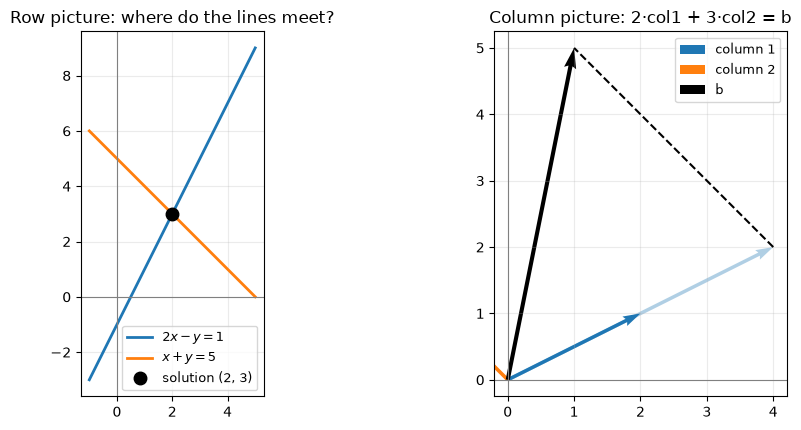

In [2]:
A = np.array([[2.0, -1.0],
              [1.0,  1.0]])
b = np.array([1.0, 5.0])
sol = np.linalg.solve(A, b)
print("solution:", sol)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

xs = np.linspace(-1, 5, 100)
axes[0].plot(xs, 2 * xs - 1, label="$2x - y = 1$", lw=2)
axes[0].plot(xs, 5 - xs, label="$x + y = 5$", lw=2)
axes[0].plot(*sol, "ko", ms=9, zorder=5, label=f"solution ({sol[0]:.0f}, {sol[1]:.0f})")
axes[0].set_title("Row picture: where do the lines meet?")

ax = axes[1]
for j, (col, name) in enumerate(zip(A.T, ["column 1", "column 2"])):
    ax.quiver(0, 0, *col, angles="xy", scale_units="xy", scale=1,
              color=f"C{j}", width=0.012, label=name)
    ax.quiver(0, 0, *(sol[j] * col), angles="xy", scale_units="xy", scale=1,
              color=f"C{j}", width=0.012, alpha=0.35)
step = sol[0] * A[:, 0]
ax.plot([step[0], b[0]], [step[1], b[1]], "k--", lw=1.5)
ax.quiver(0, 0, *b, angles="xy", scale_units="xy", scale=1, color="k", width=0.014, label="b")
ax.set_title(f"Column picture: {sol[0]:.0f}·col1 + {sol[1]:.0f}·col2 = b")

for ax in axes:
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.grid(alpha=0.25); ax.legend(fontsize=9); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

---
# Module II — Elimination, Built From Scratch

## II.a Three moves that never change the answer

🧠 **The intuition.** You already know the method: add a multiple of one
equation to another to knock out a variable, repeat until the system is
triangular, then back-substitute. What makes it valid is that each move is
**reversible**, so the solution set is untouched at every step.

📐 **The math.** The three elementary row operations are: swap two rows,
multiply a row by a non-zero scalar, and add a multiple of one row to another.
Applying them to the **augmented matrix** $[A \mid \mathbf{b}]$ drives it to
**reduced row echelon form** (RREF): each leading entry (a **pivot**) is 1, it is
the only non-zero entry in its column, and pivots move strictly right as you go
down.

The columns that end up with pivots are the **pivot columns**; the rest are
**free columns**, and their variables are the ones you get to choose. That split
is what Module IV is built on.

💻 **The code.** Forty lines, no library solver.

In [3]:
PIVOT_TOL = 1e-12     # <- knob: below this magnitude an entry counts as zero

def rref(M, tol=PIVOT_TOL, pivoting=True):
    """Reduced row echelon form. Returns (R, pivot_columns)."""
    R = np.array(M, dtype=float, copy=True)
    n_rows, n_cols = R.shape
    pivots, row = [], 0

    for col in range(n_cols):
        if row >= n_rows:
            break
        if pivoting:                                   # partial pivoting: take the largest
            p = row + int(np.argmax(np.abs(R[row:, col])))
        else:                                          # naive: take the first non-zero,
            candidates = np.flatnonzero(R[row:, col] != 0.0)   # however small it is
            p = row + int(candidates[0]) if len(candidates) else row
        if abs(R[p, col]) <= tol:
            continue                                   # nothing to pivot on: free column
        R[[row, p]] = R[[p, row]]                       # swap
        R[row] = R[row] / R[row, col]                   # scale the pivot to 1
        for i in range(n_rows):                         # clear the rest of the column
            if i != row and R[i, col] != 0.0:
                R[i] = R[i] - R[i, col] * R[row]
        pivots.append(col)
        row += 1
    return R, pivots


aug = np.column_stack([A, b])
R, piv = rref(aug)
print("augmented [A | b]:\n", aug)
print("\nRREF:\n", R)
print("pivot columns:", piv)
print("\nread off the solution:", R[:len(piv), -1], " | np.linalg.solve:", np.linalg.solve(A, b))

augmented [A | b]:
 [[ 2. -1.  1.]
 [ 1.  1.  5.]]

RREF:
 [[1. 0. 2.]
 [0. 1. 3.]]
pivot columns: [0, 1]

read off the solution: [2. 3.]  | np.linalg.solve: [2. 3.]


## II.b Why the pivoting step is not optional

🧠 **The intuition.** In exact arithmetic, any non-zero entry works as a pivot.
In floating point, dividing by a *tiny* pivot creates a gigantic multiplier, and
adding a gigantic number to an ordinary one obliterates the ordinary one: add
1 to $10^{18}$ and then subtract $10^{18}$ again, and float64 hands you 0,
because the 1 was gone the moment it landed.

**Partial pivoting** avoids it by always choosing the largest available entry in
the column, so every multiplier has magnitude $\le 1$.

📐 **The math.** The classic example:

$$ \begin{bmatrix} 10^{-18} & 1 \\ 1 & 1 \end{bmatrix}
\begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 1 \\ 2 \end{bmatrix} $$

whose true solution is very close to $x = y = 1$. Nothing about this matrix is
ill-conditioned. It is a perfectly ordinary system that only the *algorithm* can
ruin.

💻 **The code.** Same routine, pivoting on and off.

In [4]:
A_tiny = np.array([[1e-18, 1.0],
                   [1.0,   1.0]])
b_tiny = np.array([1.0, 2.0])
exact = np.array([1.0, 1.0])          # to 18 significant figures

for use_pivoting in (False, True):
    # tol=0 so that the 1e-18 entry counts as a usable pivot rather than as zero
    Rt, _ = rref(np.column_stack([A_tiny, b_tiny]), tol=0.0, pivoting=use_pivoting)
    x = Rt[:2, -1]
    err = np.linalg.norm(x - exact)
    print(f"pivoting={str(use_pivoting):<5}  x = {x}   error = {err:.1e}")

print("\nnp.linalg.solve (which pivots internally):", np.linalg.solve(A_tiny, b_tiny))
print("\nThe naive answer is not slightly wrong. The first component is 100% wrong.")

pivoting=False  x = [0. 1.]   error = 1.0e+00
pivoting=True   x = [1. 1.]   error = 0.0e+00

np.linalg.solve (which pivots internally): [1. 1.]

The naive answer is not slightly wrong. The first component is 100% wrong.


This is the whole reason `np.linalg.solve` exists rather than a five-line loop
everyone writes themselves. The mathematics is identical; the *ordering* is what
makes the arithmetic survive. It is also why the rest of this course uses
`solve(A, b)` rather than `inv(A) @ b`, and Chapter 6 measures the difference.

---
# Module III — Rank, and the Three Outcomes

🧠 **The intuition.** After elimination, count the pivots. That number is the
**rank** $r$, the number of genuinely independent equations and equivalently
(Chapter 2) the number of independent columns. Everything about solvability
follows from comparing $r$ with the number of unknowns $n$, and from asking
whether $\mathbf{b}$ introduced a new pivot of its own.

📐 **The math.** For $A$ with $n$ columns:

| Condition | Outcome |
|---|---|
| $\text{rank}[A \mid \mathbf{b}] > \text{rank}(A)$ | **no solution**: elimination produced $0 = 1$ |
| $\text{rank}(A) = n$, consistent | **exactly one** solution |
| $\text{rank}(A) < n$, consistent | **infinitely many**: $n - r$ free variables |

The first condition is the column-picture statement "$\mathbf{b}$ is outside the
span of the columns" in computational form: if adding $\mathbf{b}$ to the matrix
raises the rank, then $\mathbf{b}$ was pointing somewhere the columns cannot
reach.

💻 **The code.** One classifier, three systems.

In [5]:
def classify(Amat, bvec, name=""):
    n = Amat.shape[1]
    Raug, piv_aug = rref(np.column_stack([Amat, bvec]))
    r_A = len(rref(Amat)[1])
    inconsistent = (n in piv_aug)             # a pivot in the b column means 0 = 1
    if inconsistent:
        verdict = "NO solution"
    elif r_A == n:
        verdict = "exactly ONE solution"
    else:
        verdict = f"INFINITELY many solutions ({n - r_A} free variable(s))"
    print(f"{name}\n    rank(A) = {r_A}   rank[A|b] = {len(piv_aug)}   unknowns = {n}   -> {verdict}")
    return verdict


classify(np.array([[2.0, -1.0], [1.0, 1.0]]), np.array([1.0, 5.0]),
         "two lines crossing")
classify(np.array([[1.0, 2.0], [2.0, 4.0]]), np.array([3.0, 7.0]),
         "two parallel lines (same slope, different offset)")
_ = classify(np.array([[1.0, 2.0], [2.0, 4.0]]), np.array([3.0, 6.0]),
             "the same line written twice")

two lines crossing
    rank(A) = 2   rank[A|b] = 2   unknowns = 2   -> exactly ONE solution
two parallel lines (same slope, different offset)
    rank(A) = 1   rank[A|b] = 2   unknowns = 2   -> NO solution
the same line written twice
    rank(A) = 1   rank[A|b] = 1   unknowns = 2   -> INFINITELY many solutions (1 free variable(s))


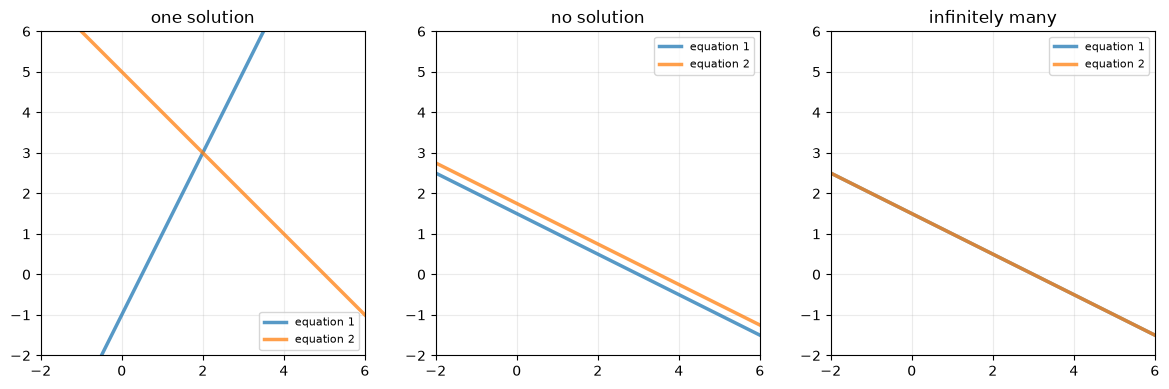

Middle: the lines are parallel, so nothing satisfies both.
Right : the two equations are the same line, so every point on it is a solution.


In [6]:
systems = [
    (np.array([[2.0, -1.0], [1.0, 1.0]]), np.array([1.0, 5.0]), "one solution"),
    (np.array([[1.0, 2.0], [2.0, 4.0]]), np.array([3.0, 7.0]), "no solution"),
    (np.array([[1.0, 2.0], [2.0, 4.0]]), np.array([3.0, 6.0]), "infinitely many"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
xs = np.linspace(-2, 6, 100)
for ax, (Am, bv, title) in zip(axes, systems):
    for i in range(2):
        a1, a2 = Am[i]
        if abs(a2) > 1e-12:
            ax.plot(xs, (bv[i] - a1 * xs) / a2, lw=2.5, alpha=0.75, label=f"equation {i+1}")
    ax.set_title(title); ax.set_xlim(-2, 6); ax.set_ylim(-2, 6)
    ax.grid(alpha=0.25); ax.legend(fontsize=8); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

print("Middle: the lines are parallel, so nothing satisfies both.")
print("Right : the two equations are the same line, so every point on it is a solution.")

---
# Module IV — The Complete Solution

## IV.a Particular + null space

🧠 **The intuition.** Suppose you have one solution in hand, and also some
vector the map destroys. Add the destroyed vector to your solution and you
still have a solution, because the extra piece contributes nothing on arrival.
Anything the matrix destroys can be added to a solution for free — and every
solution arises this way: a particular solution plus something invisible.

📐 **The math.** The **null space** (or kernel) is

$$ N(A) = \{\mathbf{x} : A\mathbf{x} = \mathbf{0}\} $$

a subspace, and if $\mathbf{x}_p$ is any particular solution of
$A\mathbf{x} = \mathbf{b}$, the complete solution set is

$$ \{\mathbf{x}_p + \mathbf{n} : \mathbf{n} \in N(A)\} $$

which is the null space **shifted** to pass through $\mathbf{x}_p$. Recall
Chapter 1: that shifted object is an *affine* set rather than a subspace, unless
$\mathbf{b} = \mathbf{0}$, in which case $\mathbf{x}_p = \mathbf{0}$ works and
the solution set is the null space itself.

The null space also answers the uniqueness question outright: the solution is
unique **exactly when** $N(A) = \{\mathbf{0}\}$, because otherwise you can always
add something invisible.

💻 **The code.** Read both pieces straight out of the RREF.

In [7]:
def solve_completely(Amat, bvec, tol=PIVOT_TOL):
    """Return (particular solution, null-space basis) read from the RREF."""
    n = Amat.shape[1]
    Raug, piv = rref(np.column_stack([Amat, bvec]), tol=tol)
    if n in piv:
        return None, None                                   # inconsistent: 0 = 1
    free = [c for c in range(n) if c not in piv]

    x_p = np.zeros(n)                                       # free variables set to 0
    for i, c in enumerate(piv):
        x_p[c] = Raug[i, -1]

    basis = []
    for f in free:                                          # one null vector per free column
        v = np.zeros(n)
        v[f] = 1.0
        for i, c in enumerate(piv):
            v[c] = -Raug[i, f]
        basis.append(v)
    return x_p, (np.column_stack(basis) if basis else np.zeros((n, 0)))


A3 = np.array([[1.0, 2.0, 3.0],
               [2.0, 4.0, 8.0],
               [1.0, 2.0, 5.0]])
b3 = np.array([6.0, 16.0, 10.0])

x_p, N = solve_completely(A3, b3)
print("A =\n", A3, "\nb =", b3)
print("\nparticular solution x_p :", x_p, "  check A x_p =", A3 @ x_p)
print("null space basis (columns):\n", N)
print("check A n = 0:", np.allclose(A3 @ N, 0))

print("\nthe complete solution set is x_p + t·n:")
for t in [0.0, 1.0, -3.5]:
    x = x_p + t * N[:, 0]
    print(f"    t = {t:>5}:  x = {np.round(x, 3)}   ->   A x = {np.round(A3 @ x, 6)}")

A =
 [[1. 2. 3.]
 [2. 4. 8.]
 [1. 2. 5.]] 
b = [ 6. 16. 10.]

particular solution x_p : [0. 0. 2.]   check A x_p = [ 6. 16. 10.]
null space basis (columns):
 [[-2.]
 [ 1.]
 [ 0.]]
check A n = 0: True

the complete solution set is x_p + t·n:
    t =   0.0:  x = [0. 0. 2.]   ->   A x = [ 6. 16. 10.]
    t =   1.0:  x = [-2.  1.  2.]   ->   A x = [ 6. 16. 10.]
    t =  -3.5:  x = [ 7.  -3.5  2. ]   ->   A x = [ 6. 16. 10.]


## IV.b The solution set is a line in space

With one free variable the solution set is a line: the null-space direction,
shifted so it passes through $\mathbf{x}_p$. It misses the origin (unless
$\mathbf{b} = \mathbf{0}$), which is exactly why it is not a subspace.

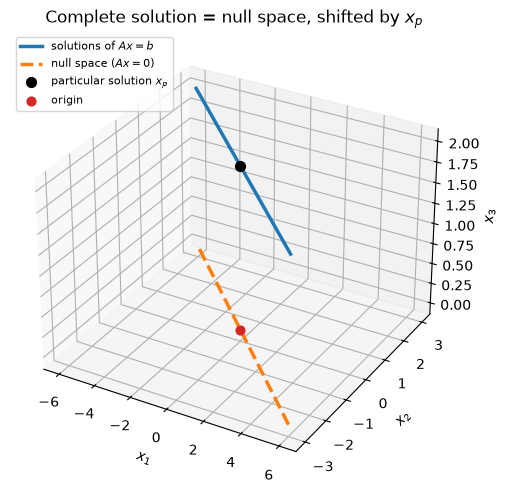

In [8]:
fig = plt.figure(figsize=(6.5, 5))
ax = fig.add_subplot(projection="3d")
ts = np.linspace(-3, 3, 50)

line = x_p[:, None] + N[:, 0][:, None] * ts                       # solutions of A x = b
null = N[:, 0][:, None] * ts                                      # solutions of A x = 0
ax.plot(*line, lw=2.5, color="tab:blue", label="solutions of $A x = b$")
ax.plot(*null, lw=2.5, color="tab:orange", ls="--", label="null space ($A x = 0$)")
ax.scatter(*x_p, color="k", s=50, label="particular solution $x_p$")
ax.scatter(0, 0, 0, color="tab:red", s=40, label="origin")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_zlabel("$x_3$")
ax.set_title("Complete solution = null space, shifted by $x_p$")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

---
# Module V — The Four Fundamental Subspaces

## V.a Two spaces for $A$, two for $A^\top$

🧠 **The intuition.** A matrix $A$ ($m \times n$) has an input side
($\mathbb{R}^n$) and an output side ($\mathbb{R}^m$), and each side splits in two.
On the **input** side sit the directions that get **destroyed** (the null space)
and the directions that survive (the row space). On the **output** side sit the
directions that can be **reached** (the column space) and the directions that
cannot (the left null space).

📐 **The math.**

| Subspace | Definition | Lives in | Dimension |
|---|---|---|---|
| Column space $C(A)$ | all $A\mathbf{x}$ | $\mathbb{R}^m$ | $r$ |
| Null space $N(A)$ | all $\mathbf{x}$ with $A\mathbf{x} = \mathbf{0}$ | $\mathbb{R}^n$ | $n - r$ |
| Row space $C(A^\top)$ | all $A^\top\mathbf{y}$ | $\mathbb{R}^n$ | $r$ |
| Left null space $N(A^\top)$ | all $\mathbf{y}$ with $A^\top\mathbf{y} = \mathbf{0}$ | $\mathbb{R}^m$ | $m - r$ |

Two facts do a lot of work. First, **row rank equals column rank**, so the same
$r$ appears twice, which is not obvious and is one of the most useful theorems in
the subject. Second, the **rank–nullity theorem**:

$$ \underbrace{r}_{\text{dimensions that survive}} + \underbrace{(n - r)}_{\text{dimensions destroyed}} = n $$

Every input dimension is either carried through or crushed; nothing else can
happen to it.

💻 **The code.** Measure all four on random matrices of prescribed rank.

In [9]:
def subspace_report(Amat, name=""):
    m, n = Amat.shape
    r = np.linalg.matrix_rank(Amat)
    row_rank = np.linalg.matrix_rank(Amat.T)
    _, Nb = solve_completely(Amat, np.zeros(m))
    print(f"{name}  A is {m}x{n}, rank {r}")
    print(f"    column space: dim {r:<2}  in R^{m}      null space: dim {n - r:<2}  in R^{n}")
    print(f"    row space:    dim {row_rank:<2}  in R^{n}      left null:  dim {m - r:<2}  in R^{m}")
    print(f"    rank + nullity = {r} + {n - r} = {n} = number of columns "
          f"[{'OK' if r + (n - r) == n else 'FAIL'}]")
    print(f"    row rank == column rank: {row_rank == r}")
    print(f"    null-space basis found by elimination has {Nb.shape[1]} vector(s), "
          f"A @ N = 0: {np.allclose(Amat @ Nb, 0)}\n")

subspace_report(A3, "the 3x3 from Module IV:")
subspace_report(rng.normal(size=(4, 6)), "random 4x6 (full row rank):")
subspace_report(rng.normal(size=(6, 4)), "random 6x4 (full column rank):")
low = rng.normal(size=(5, 2)) @ rng.normal(size=(2, 5))       # rank 2 by construction
subspace_report(low, "5x5 built as (5x2)(2x5), so rank 2:")

the 3x3 from Module 4:  A is 3x3, rank 2
    column space: dim 2   in R^3      null space: dim 1   in R^3
    row space:    dim 2   in R^3      left null:  dim 1   in R^3
    rank + nullity = 2 + 1 = 3 = number of columns [OK]
    row rank == column rank: True
    null-space basis found by elimination has 1 vector(s), A @ N = 0: True

random 4x6 (full row rank):  A is 4x6, rank 4
    column space: dim 4   in R^4      null space: dim 2   in R^6
    row space:    dim 4   in R^6      left null:  dim 0   in R^4
    rank + nullity = 4 + 2 = 6 = number of columns [OK]
    row rank == column rank: True
    null-space basis found by elimination has 2 vector(s), A @ N = 0: True

random 6x4 (full column rank):  A is 6x4, rank 4
    column space: dim 4   in R^6      null space: dim 0   in R^4
    row space:    dim 4   in R^4      left null:  dim 2   in R^6
    rank + nullity = 4 + 0 = 4 = number of columns [OK]
    row rank == column rank: True
    null-space basis found by elimination has 0 vect

## V.b The right angle nobody mentions in the definition

🧠 **The intuition.** The row space and null space share more than complementary
dimensions inside $\mathbb{R}^n$. They are **perpendicular**. The reason sits in
plain sight in the definition: a null-space vector is one that *every row of $A$
hits with a zero dot product*, and a zero dot product is exactly what
"perpendicular" means.

📐 **The math.** $N(A) \perp C(A^\top)$ in $\mathbb{R}^n$, and
$N(A^\top) \perp C(A)$ in $\mathbb{R}^m$. Each pair carves its space into two
orthogonal pieces whose dimensions add to the whole.

💻 **The code.** Measure the angles rather than take this on faith.

In [10]:
Am = rng.normal(size=(4, 2)) @ rng.normal(size=(2, 5))      # 4x5, rank 2 by construction
_, Nb = solve_completely(Am, np.zeros(Am.shape[0]))

dots = [abs(row @ Nb[:, j]) for row in Am for j in range(Nb.shape[1])]
print(f"A is {Am.shape[0]}x{Am.shape[1]}, rank {np.linalg.matrix_rank(Am)}, "
      f"null space dimension {Nb.shape[1]}")
print(f"largest |row · null vector| over {len(dots)} pairs: {max(dots):.2e}   (0 = perpendicular)")

# and the same statement for the output side
left_null = solve_completely(Am.T, np.zeros(Am.shape[1]))[1]
cols_dots = [abs(Am[:, j] @ left_null[:, k])
             for j in range(Am.shape[1]) for k in range(left_null.shape[1])]
print(f"largest |column · left-null vector|: {max(cols_dots):.2e}")
print("\nThe row space and null space meet at right angles, which is what makes")
print("Chapter 7's projections work, and what the SVD in Chapter 9 exploits.")

A is 4x5, rank 2, null space dimension 3
largest |row · null vector| over 12 pairs: 1.39e-16   (0 = perpendicular)
largest |column · left-null vector|: 5.55e-17

The row space and null space meet at right angles, which is what makes
Chapter 7's projections work, and what the SVD in Chapter 9 exploits.


---
# Module VI — A System With a Point: Fitting a Polynomial

🧠 **The intuition.** Three points in the plane, and you want the parabola
through them. A parabola has three dials — a constant, a linear coefficient,
and a quadratic one — and demanding that the curve pass through a point pins
one linear constraint on those dials. Three points, three constraints, three
unknowns: a square system. The matrix that shows up has a name, the
**Vandermonde matrix**, and its columns are the basis polynomials $1, x, x^2$
evaluated at the data points.

📐 **The math.** Write $p(x) = c_0 + c_1x + c_2x^2$; the three conditions
$p(x_i) = y_i$ stack into

$$ \begin{bmatrix} 1 & x_1 & x_1^2 \\ 1 & x_2 & x_2^2 \\ 1 & x_3 & x_3^2 \end{bmatrix}
\begin{bmatrix} c_0 \\ c_1 \\ c_2 \end{bmatrix} =
\begin{bmatrix} y_1 \\ y_2 \\ y_3 \end{bmatrix} $$

For distinct $x_i$ this matrix has full rank, so there is exactly one such
parabola.

💻 **The code.**

Vandermonde matrix:
 [[ 1.   -1.    1.  ]
 [ 1.    0.5   0.25]
 [ 1.    2.    4.  ]]

coefficients [c0, c1, c2]: [-0.667 -1.667  2.   ]
fits every point exactly: True


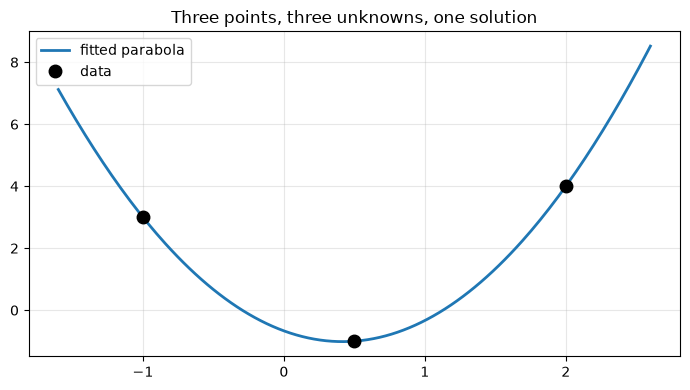

In [11]:
pts_x = np.array([-1.0, 0.5, 2.0])
pts_y = np.array([3.0, -1.0, 4.0])

V = np.vander(pts_x, 3, increasing=True)         # columns: 1, x, x^2
coef = np.linalg.solve(V, pts_y)

print("Vandermonde matrix:\n", V)
print("\ncoefficients [c0, c1, c2]:", np.round(coef, 4))
print("fits every point exactly:", np.allclose(V @ coef, pts_y))

grid = np.linspace(-1.6, 2.6, 200)
plt.figure(figsize=(7, 4))
plt.plot(grid, np.vander(grid, 3, increasing=True) @ coef, lw=2, label="fitted parabola")
plt.plot(pts_x, pts_y, "ko", ms=9, label="data")
plt.grid(alpha=0.3); plt.legend(); plt.title("Three points, three unknowns, one solution")
plt.tight_layout(); plt.show()

Now add a fourth point. Four equations, still three unknowns. The system is
**overdetermined**, and unless the new point happens to lie on the parabola
already, there is no solution at all.

four points, three unknowns:
    rank(A) = 3   rank[A|b] = 4   unknowns = 3   -> NO solution

solve_completely returns: None  (None = inconsistent, exactly as classified)

least-squares 'solution': [ 1.205 -0.731  0.454]
residual per point: [-0.61   1.953 -2.441  1.098]


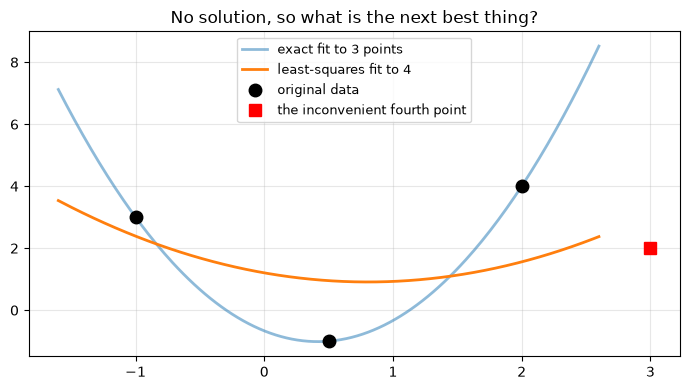

In [12]:
EXTRA_POINT = (3.0, 2.0)                         # <- knob: the inconvenient 4th point
pts_x4 = np.append(pts_x, EXTRA_POINT[0])
pts_y4 = np.append(pts_y, EXTRA_POINT[1])        # deliberately off the parabola
V4 = np.vander(pts_x4, 3, increasing=True)

classify(V4, pts_y4, "four points, three unknowns:")

x_p4, _ = solve_completely(V4, pts_y4)
print("\nsolve_completely returns:", x_p4, " (None = inconsistent, exactly as classified)")

best, *_ = np.linalg.lstsq(V4, pts_y4, rcond=None)      # the closest thing to a solution
print("\nleast-squares 'solution':", np.round(best, 4))
print("residual per point:", np.round(V4 @ best - pts_y4, 4))

plt.figure(figsize=(7, 4))
plt.plot(grid, np.vander(grid, 3, increasing=True) @ coef, lw=2, alpha=0.5, label="exact fit to 3 points")
plt.plot(grid, np.vander(grid, 3, increasing=True) @ best, lw=2, label="least-squares fit to 4")
plt.plot(pts_x, pts_y, "ko", ms=9, label="original data")
plt.plot(pts_x4[-1], pts_y4[-1], "rs", ms=9, label="the inconvenient fourth point")
plt.grid(alpha=0.3); plt.legend(fontsize=9); plt.title("No solution, so what is the next best thing?")
plt.tight_layout(); plt.show()

`lstsq` returned coefficients even though the system has **no solution**, and
the residual vector shows why they are still worth having: no single point is
matched exactly, but the total miss is as small as it can be.

That is not a hack. It is a precise construction (project $\mathbf{b}$ onto the
column space, then solve the system that *is* consistent), and it is the subject
of Chapter 7. Every regression you have ever run is this cell.

---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| Row picture vs column picture | Rows intersect; columns combine. The column view is Chapter 2's span, and it survives high dimensions |
| `rref` from scratch | Elimination is three reversible moves; the pivot columns are the ones that matter |
| The $10^{-18}$ pivot disaster | Correct mathematics, ruined arithmetic. Ordering is the algorithm, which is why you call `solve` |
| `classify` on three systems | Compare $\text{rank}(A)$, $\text{rank}[A\mid\mathbf{b}]$, and $n$, and that is the entire solvability story |
| `solve_completely` | Complete solution = one particular solution + the whole null space |
| The solution line missing the origin | Solution sets are *affine*: a subspace shifted by $\mathbf{x}_p$, a subspace only when $\mathbf{b} = \mathbf{0}$ |
| Four subspaces, rank + nullity = $n$ | Every input direction is either carried through or crushed; row rank = column rank |
| $\text{row} \cdot \text{null} \approx 10^{-16}$ | The two input subspaces are perpendicular, and Chapter 7 turns that fact into an algorithm |
| Vandermonde fits, exact and impossible | Square and full-rank → one answer; overdetermined → usually none, and you need a new question |

**Where the course goes from here.** Two threads are now open.

The first is the word **invertible**. A square system has exactly one solution
for every $\mathbf{b}$ precisely when nothing is destroyed, which is to say when
the null space is trivial. **Chapter 6** attaches a single number to that
condition, the **determinant**, and shows what it measures geometrically (volume)
and why computing $A^{-1}$ is almost always the wrong move.

The second is that last plot. When $A\mathbf{x} = \mathbf{b}$ has no solution,
the right question is not "what is $\mathbf{x}$?" but "**what is the closest
thing to a solution?**" Answering that needs perpendicularity, which is
**Chapter 7**.